<a href="https://colab.research.google.com/github/busetas/Roketsan_Sensor/blob/main/03_Radar_%C4%B0z_Takibi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Otonom Sistemler & Radar İz Takibi: $\alpha$-$\beta$ Filtresi Eğitimi

Bu Notebook, karmaşık matris matematiğine (Kalman / Extended Kalman Filter) girmeden önce, **otonom bir sistemin gürültülü sensör verisinden durum kestirimi (state estimation) yapmasını** kolay bir şekilde kavramak için tasarlanmıştır.

---

## 🎯 Eğitimin Amacı ve Öğrenme Hedefleri
1. **Radar Simülasyonu:** 2B uzayda (enlem/boylam düzlemi) doğrusal hareket eden bir hedef ve bu hedefi polar koordinatlarda ($r, \theta$) ölçen gürültülü bir radar modeli oluşturmak.
2. **Koordinat Dönüşümü:** Polar ölçümleri Kartezyen ($x, y$) dik koordinat sistemine aktarmak.
3. **$\alpha$-$\beta$ Tracker (İz Takipçisi):** "Tahmin $\rightarrow$ Düzeltme" (Predict $\rightarrow$ Update) döngüsünü anlamak ve gürültüyü süzerek yumuşak bir iz (track) elde etmek.

---

## 📐 Teorik Arka Plan

### 1. Radar Ölçüm Modeli (Polar Koordinatlar)
Radarımız hedefin uzaklığını (Menzil / Range $r$) ve açısını (Yanca / Azimuth $\theta$) ölçer. Ancak fiziksel sensörler mükemmel değildir; ölçümlere **Gauss (Normal) gürültüsü** eklenir:

$$r_{ölçüm} = \sqrt{x^2 + y^2} + \mathcal{N}(0, \sigma_r^2)$$

$$\theta_{ölçüm} = \arctan\left(\frac{y}{x}\right) + \mathcal{N}(0, \sigma_\theta^2)$$

### 2. Kartezyen Dönüşüm
Gürültülü polar veriyi iz takipçisine beslemeden önce Kartezyen düzleme çeviririz:

$$x_{m} = r_{ölçüm} \cdot \cos(\theta_{ölçüm})$$

$$y_{m} = r_{ölçüm} \cdot \sin(\theta_{ölçüm})$$

### 3. $\alpha$-$\beta$ Filtresi Mantığı
Filtre iki ana adımdan oluşur:

#### **A. Tahmin Adımı (Predict):**
Geçmiş konum ve hız bilgisine dayanarak bir sonraki adımda hedefin nerede olacağı tahmin edilir ($dt$: radar tarama periyodu):

$$\hat{x}_{tahmin} = x_{eski} + v_x \cdot dt$$

$$\hat{y}_{tahmin} = y_{eski} + v_y \cdot dt$$

#### **B. Güncelleme Adımı (Update):**
Radar ölçümü ile yapılan tahmin arasındaki **fark (Yenilik / Innovation / Residual)** bulunur:

$$e_x = x_m - \hat{x}_{tahmin}, \quad e_y = y_m - \hat{y}_{tahmin}$$

Bu fark $\alpha$ ve $\beta$ katsayıları ile ölçeklenerek konum ve hız güncellenir:

$$x_{yeni} = \hat{x}_{tahmin} + \alpha \cdot e_x$$

$$v_{x, yeni} = v_{x, eski} + \frac{\beta}{dt} \cdot e_x$$

> 💡 **Kilit Parametreler:**
> * **$\alpha$ (Konum Düzeltme Paramaetresi):** 1'e yaklaştıkça ölçüme daha çok güvenir (gürültüyü aynen alır), 0'a yaklaştıkça modele/tahmine güvenir.
> * **$\beta$ (Hız Düzeltme Parametresi):** Hızın ölçüm hatalarından ne kadar hızlı etkileneceğini belirler.

---

## 🛠️ UYGULAMA: Python Kod Bloğu

Aşağıdaki Python kodunu Jupyter Notebook hücrenizde çalıştırabilirsiniz.


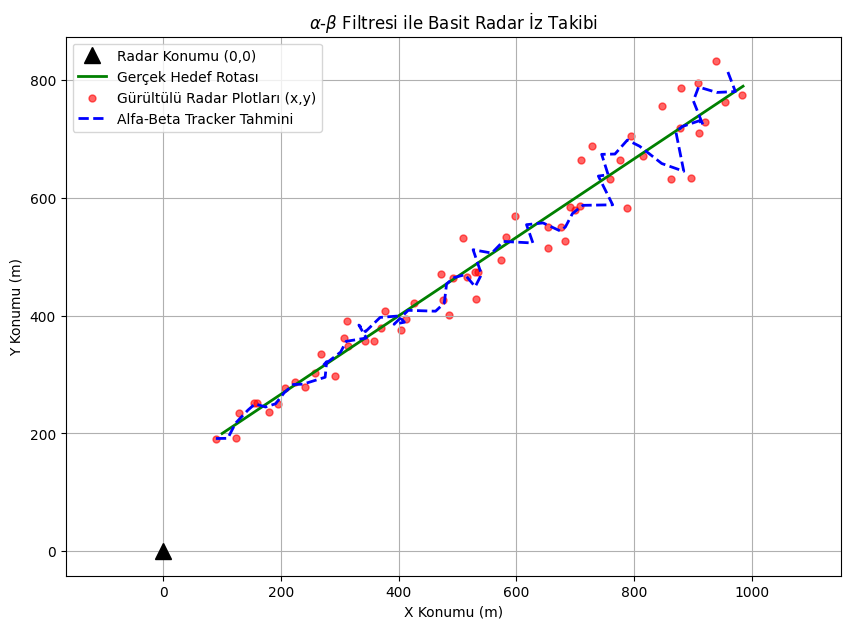

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SİMÜLASYON EKRAI (RADAR VERİ ÜRETİCİ)
# ==========================================
class RadarSimulation:
    def __init__(self, dt, sigma_r, sigma_az):
        self.dt = dt
        self.sigma_r = sigma_r      # Menzil gürültüsü (metre)
        self.sigma_az = sigma_az    # Azimuth gürültüsü (radyan)

    def generate_data(self, num_steps, x0, y0, vx, vy):
        true_states = []
        measurements_cartesian = []

        x, y = x0, y0
        for _ in range(num_steps):
            # 1. Gerçek Durum
            true_states.append([x, y])

            # 2. Polar Dönüşüm
            r_true = np.sqrt(x**2 + y**2)
            az_true = np.arctan2(y, x)

            # 3. Gauss Gürültüsü Ekleme
            r_meas = r_true + np.random.normal(0, self.sigma_r)
            az_meas = az_true + np.random.normal(0, self.sigma_az)

            # 4. Plot'u Tracker'a göndermek için tekrar Kartezyene çevirme (x_m, y_m)
            x_meas = r_meas * np.cos(az_meas)
            y_meas = r_meas * np.sin(az_meas)
            measurements_cartesian.append([x_meas, y_meas])

            # Hedefin hareketi
            x += vx * self.dt
            y += vy * self.dt

        return np.array(true_states), np.array(measurements_cartesian)


# ==========================================
# 2. TRACKER (ALFA-BETA FİLTRESİ)
# ==========================================
class AlphaBetaTracker2D:
    def __init__(self, dt, alpha=0.85, beta=0.005):
        self.dt = dt
        self.alpha = alpha  # Konum düzeltme ağırlığı
        self.beta = beta    # Hız düzeltme ağırlığı

        # Durum Değişkenleri
        self.x = 0.0
        self.y = 0.0
        self.vx = 0.0
        self.vy = 0.0

    def initialize(self, first_meas_x, first_meas_y):
        """İlklendirme: İlk plot doğrudan konum kabul edilir, hız sıfır başlar."""
        self.x = first_meas_x
        self.y = first_meas_y
        self.vx = 0.0
        self.vy = 0.0

    def process_step(self, z_x, z_y):
        # --- 1. TAHMİN ADIMI (PREDICT) ---
        x_pred = self.x + self.vx * self.dt
        y_pred = self.y + self.vy * self.dt
        vx_pred = self.vx
        vy_pred = self.vy

        # --- 2. YENİLİK / FARK (RESIDUAL) ---
        residual_x = z_x - x_pred
        residual_y = z_y - y_pred

        # --- 3. GÜNCELLEME ADIMI (UPDATE) ---
        self.x = x_pred + self.alpha * residual_x
        self.y = y_pred + self.alpha * residual_y

        self.vx = vx_pred + (self.beta / self.dt) * residual_x
        self.vy = vy_pred + (self.beta / self.dt) * residual_y

        return self.x, self.y


# ==========================================
# 3. ÇALIŞTIRMA VE GÖRSELLEŞTİRME
# ==========================================
if __name__ == "__main__":
    dt = 1.0                # Radar periyodu (s)
    num_steps = 60          # Adım sayısı
    sigma_r = 20.0          # Menzil gürültüsü (m)
    sigma_az = np.deg2rad(2.0) # Azimuth gürültüsü (rad)

    # 1. Simülasyon Verisini Üret
    sim = RadarSimulation(dt, sigma_r, sigma_az)
    true_path, measurements = sim.generate_data(num_steps, x0=100, y0=200, vx=15, vy=10)

    # 2. Alfa-Beta Tracker'ı Çalıştır
    # Alpha yüksek seçilirse gürültüye hassas olur, düşük seçilirse hedefin manevralarına geç tepki verir.
    tracker = AlphaBetaTracker2D(dt, alpha=0.6, beta=0.1)
    tracker.initialize(measurements[0, 0], measurements[0, 1])

    tracked_path = []
    for z_x, z_y in measurements:
        pos_x, pos_y = tracker.process_step(z_x, z_y)
        tracked_path.append([pos_x, pos_y])

    tracked_path = np.array(tracked_path)

    # 3. Çizim
    plt.figure(figsize=(10, 7))
    plt.plot(0, 0, 'k^', markersize=12, label='Radar Konumu (0,0)')
    plt.plot(true_path[:, 0], true_path[:, 1], 'g-', linewidth=2, label='Gerçek Hedef Rotası')
    plt.scatter(measurements[:, 0], measurements[:, 1], color='red', alpha=0.6, s=25, label='Gürültülü Radar Plotları (x,y)')
    plt.plot(tracked_path[:, 0], tracked_path[:, 1], 'b--', linewidth=2, label='Alfa-Beta Tracker Tahmini')

    plt.title(r'$\alpha$-$\beta$ Filtresi ile Basit Radar İz Takibi')
    plt.xlabel('X Konumu (m)')
    plt.ylabel('Y Konumu (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# 🧠 $\alpha$-$\beta$'dan Kalman Filtresine ($KF$) Geçiş

$\alpha$-$\beta$ filtresinde $\alpha$ (konum düzeltme) ve $\beta$ (hız düzeltme) değerlerini elle sabit olarak seçmiştik. Ancak gerçek dünyada:
1. Sensör gürültüsü anlık olarak değişebilir.
2. Model belirsizliklerimiz (rüzgar, ani ivmelenme vb.) sabit değildir.

**Kalman Filtresi**, bu düzeltme katsayılarını her adımda optimal (en ideal) şekilde otomatik hesaplar. $KF$'de $\alpha$ ve $\beta$ yerine matris formundaki **Kalman Kazancı ($K$)** kullanılır.

---

## 📐 Kalman Filtresi Denklemleri ve Matematiksel Altyapı

Kalman Filtresi tam olarak iki adımdan oluşan bir döngüdür: **Tahmin (Predict)** ve **Güncelleme (Update)**.

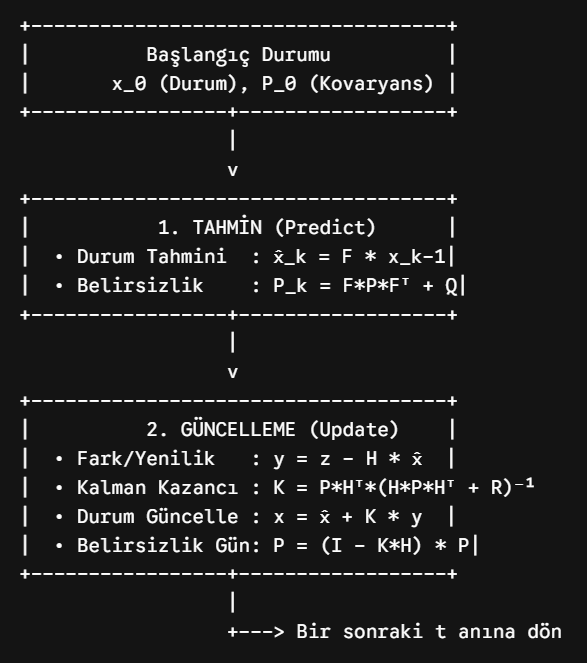

---

### 1. Temel Vektör ve Matris Tanımları

* **Durum Vektörü ($x$):** Sistemin takip etmek istediğimiz değişkenleri ($4 \times 1$).
  $$x = \begin{bmatrix} x \\ y \\ v_x \\ v_y \end{bmatrix}$$

* **Durum Geçiş Matrisi ($F$):** Fizik kurallarına dayalı hareket modelimiz ($4 \times 4$). Sabit hızlı ($CV$) hareket için:
  $$F = \begin{bmatrix} 1 & 0 & dt & 0 \\ 0 & 1 & 0 & dt \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

* **Ölçüm Matrisi ($H$):** Durum vektörünü sensör ölçümlerine bağlayan matris ($2 \times 4$). Sensörümüz Kartezyen uzayda doğrudan $(x,y)$ ölçüyorsa:
  $$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

* **Kovaryans Matrisleri (Belirsizlikler):**
  * $P$ ($4 \times 4$): Tahminimizin ne kadar belirsiz/güvenilmez olduğunu gösteren **Durum Belirsizlik Matrisi**.
  * $Q$ ($4 \times 4$): Modeldeki eksikliklerden (rüzgar, ani manevra vb.) kaynaklanan **Süreç Gürültüsü (Process Noise)**.
  * $R$ ($2 \times 2$): Sensörün kendi fiziksel hatasından kaynaklanan **Ölçüm Gürültüsü (Measurement Noise)**:
  $$R = \begin{bmatrix} \sigma_x^2 & 0 \\ 0 & \sigma_y^2 \end{bmatrix}$$

---

### 2. İki Adımlı İterasyon Mantığı

#### **A. TAHMİN ADIMI (Predict)**
Geçmiş duruma bakılarak fizik kuralları ($F$) ile bir sonraki adım tahmin edilir:

1. **Durum Tahmini:** $\hat{x}_k = F \cdot x_{k-1}$
2. **Belirsizlik Yayılımı:** $P_k = F \cdot P_{k-1} \cdot F^T + Q$

*(Tahmin yaptıkça belirsizliğimiz $P$ büyür, çünkü henüz yeni bir sensör verisi görmedik!)*

#### **B. GÜNCELLEME ADIMI (Update)**
Sensörden yeni bir ölçüm ($z$) geldiğinde tahmin düzeltilir:

1. **Ölçüm Farkı / Yenilik ($y$):** $y = z - H \cdot \hat{x}_k$  *(Ölçüm ile Tahmin Arasındaki Fark)*
2. **Kalman Kazancı ($K$):**
   $$K = P_k \cdot H^T \cdot (H \cdot P_k \cdot H^T + R)^{-1}$$
   *(Bu matris $\alpha$ ve $\beta$'nın matrisel karşılığıdır! Eğer sensör gürültüsü $R$ küçükse $K$ büyür ve ölçüme güvenir; model gürültüsü $Q$ küçükse $K$ küçülür ve tahmine güvenir.)*
3. **Durum Güncelleme:** $x_k = \hat{x}_k + K \cdot y$
4. **Belirsizlik Güncelleme:** $P_k = (I - K \cdot H) \cdot P_k$  *(Sensör verisi gördüğümüz için belirsizlik $P$ küçülür!)*

---

## ⚡ Neden Standart KF Yetmez, EKF'e İhtiyaç Duyarız?

Buradaki standart Kalman Filtresi denklemlerinde $H$ matrisinin sabit ve doğrusal (linear) olduğu varsayılır.

Ancak bizim radarımız **Polar Koordinatlarda ($r, \theta$)** ölçüm yapmaktadır:
$$r = \sqrt{x^2 + y^2}$$
$$\theta = \arctan\left(\frac{y}{x}\right)$$

Bu ilişkiler **trigonometrik ve dik açı karekökleri içerdiği için doğrusal değildir (non-linear)**. Doğrusal olmayan bu dönüşümü $H$ matrisi ile ifade edemediğimiz için **Genişletilmiş Kalman Filtresi'ne (EKF)** geçeriz. EKF, bu non-lineer denklemlerin türevini alarak (**Jacobian Matrisi**) anlık doğrusal yaklaşımlar (linearization) üretir.

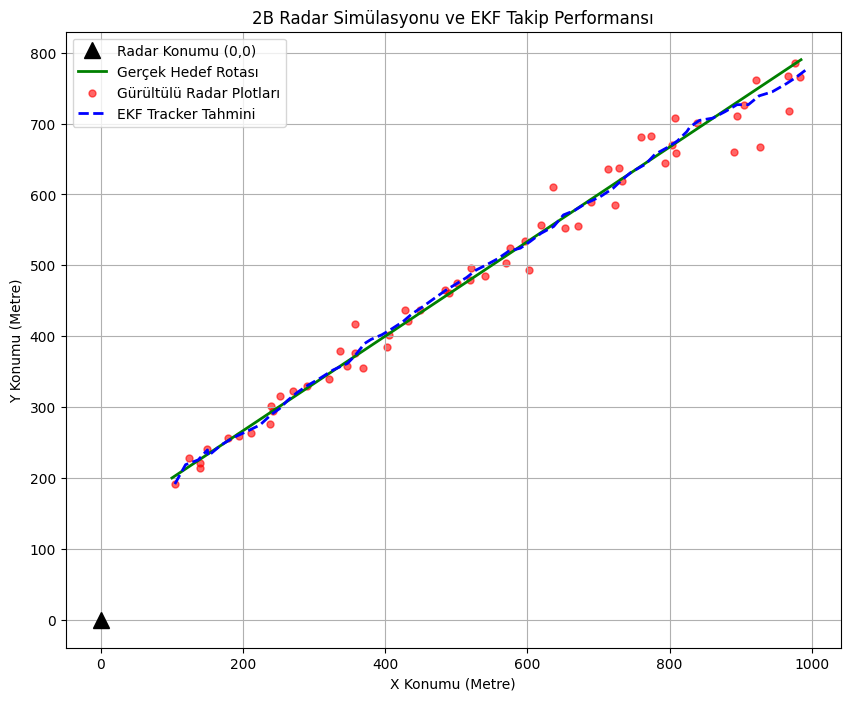

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SİMÜLASYON VERİ ÜRETİCİSİ (RADAR)
# ==========================================
class RadarSimulation:
    def __init__(self, dt, sigma_r, sigma_az):
        self.dt = dt
        self.sigma_r = sigma_r      # Menzil gürültüsü standart sapması (metre)
        self.sigma_az = sigma_az    # Azimuth gürültüsü standart sapması (radyan)

    def generate_trajectory(self, num_steps, x0, y0, vx, vy):
        """Düzgün doğrusal hareket yapan gerçek hedef rotası oluşturur."""
        true_states = []
        x, y = x0, y0
        for _ in range(num_steps):
            true_states.append([x, y, vx, vy])
            x += vx * self.dt
            y += vy * self.dt
        return np.array(true_states)

    def generate_measurements(self, true_states):
        """Gerçek konumları gürültülü polar radar ölçümlerine (r, azimuth) dönüştürür."""
        measurements = []
        for state in true_states:
            x, y = state[0], state[1]

            # Gerçek Polar Koordinatlar
            r_true = np.sqrt(x**2 + y**2)
            az_true = np.arctan2(y, x)

            # Gauss Gürültüsü Ekleme
            r_meas = r_true + np.random.normal(0, self.sigma_r)
            az_meas = az_true + np.random.normal(0, self.sigma_az)

            measurements.append([r_meas, az_meas])
        return np.array(measurements)


# ==========================================
# 2. TRACKER (EXTENDED KALMAN FILTER - EKF)
# ==========================================
class RadarEKF:
    def __init__(self, dt, sigma_r, sigma_az, q_var):
        self.dt = dt
        self.sigma_r = sigma_r
        self.sigma_az = sigma_az

        # Durum Vektörü: [x, y, vx, vy]^T
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 500.0  # Başlangıç belirsizlik matrisi

        # Durum Geçiş Matrisi (F) - Sabit Hız Modeli
        self.F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ])

        # Süreç Gürültüsü Matrisi (Q)
        q1 = 0.5 * (dt**2)
        G = np.array([[q1, 0], [0, q1], [dt, 0], [0, dt]])
        self.Q = G @ G.T * q_var

        # Ölçüm Gürültüsü Kovaryansı (R)
        self.R = np.diag([sigma_r**2, sigma_az**2])

    def initialize(self, r_meas, az_meas):
        """İlk plot ile filitreyi ilklendirir."""
        x_init = r_meas * np.cos(az_meas)
        y_init = r_meas * np.sin(az_meas)
        self.x = np.array([[x_init], [y_init], [0.0], [0.0]])

    def predict(self):
        """Tahmin (Predict) Adımı"""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        """Güncelleme (Update) Adımı"""
        px, py = self.x[0, 0], self.x[1, 0]

        r_pred = np.sqrt(px**2 + py**2)
        az_pred = np.arctan2(py, px)

        # Beklenen Ölçüm Fonksiyonu h(x)
        h_x = np.array([[r_pred], [az_pred]])

        # Jacobian Matrisi (H)
        if r_pred < 1e-5:
            return  # Sıfıra bölünme hatasını önle

        r2 = r_pred**2
        H = np.array([
            [px / r_pred,  py / r_pred,  0, 0],
            [-py / r2,     px / r2,      0, 0]
        ])

        # Yenilik (Innovation) Vektörü
        y = z - h_x
        # Açı taşmasını [-pi, pi] aralığına yerleştirme
        y[1, 0] = (y[1, 0] + np.pi) % (2 * np.pi) - np.pi

        # Kalman Kazancı (K) Hesaplama
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)

        # Durum ve Kovaryans Güncelleme
        self.x = self.x + K @ y
        I = np.eye(4)
        self.P = (I - K @ H) @ self.P


# ==========================================
# 3. ÇALIŞTIRMA VE GÖRSELLEŞTİRME
# ==========================================
if __name__ == "__main__":
    # Parametreler
    dt = 1.0                # Radar tarama periyodu (saniye)
    num_steps = 60          # Toplam adım sayısı
    sigma_r = 15.0          # Menzil gürültüsü (m)
    sigma_az = np.deg2rad(1.5) # Azimuth gürültüsü (rad)
    q_var = 0.1             # Süreç gürültüsü ivme varyansı

    # 1. Simülasyon
    sim = RadarSimulation(dt, sigma_r, sigma_az)
    true_states = sim.generate_trajectory(num_steps, x0=100, y0=200, vx=15, vy=10)
    measurements = sim.generate_measurements(true_states)

    # 2. Takip (Tracking)
    tracker = RadarEKF(dt, sigma_r, sigma_az, q_var)
    tracker.initialize(measurements[0, 0], measurements[0, 1])

    tracked_states = []
    for z_polar in measurements:
        tracker.predict()
        z = np.array([[z_polar[0]], [z_polar[1]]])
        tracker.update(z)
        tracked_states.append(tracker.x.flatten())

    tracked_states = np.array(tracked_states)

    # 3. Plot'ların Kartezyene Dönüştürülmesi (Görselleştirme İçin)
    meas_x = measurements[:, 0] * np.cos(measurements[:, 1])
    meas_y = measurements[:, 0] * np.sin(measurements[:, 1])

    # 4. Grafik Çizimi
    plt.figure(figsize=(10, 8))
    plt.plot(0, 0, 'k^', markersize=12, label='Radar Konumu (0,0)')
    plt.plot(true_states[:, 0], true_states[:, 1], 'g-', linewidth=2, label='Gerçek Hedef Rotası')
    plt.scatter(meas_x, meas_y, color='red', alpha=0.6, s=25, label='Gürültülü Radar Plotları')
    plt.plot(tracked_states[:, 0], tracked_states[:, 1], 'b--', linewidth=2, label='EKF Tracker Tahmini')

    plt.title('2B Radar Simülasyonu ve EKF Takip Performansı')
    plt.xlabel('X Konumu (Metre)')
    plt.ylabel('Y Konumu (Metre)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

Standart Lineer Kalman Filtresi ($KF$) ile Genişletilmiş Kalman Filtresi ($EKF$) arasındaki fark, şu şekilde açıklanabilir:

- Standart Lineer KF: Radar ölçümlerini önceden $x = r \cos(\theta)$ ve $y = r \sin(\theta)$ formülüyle Kartezyen uzaya dönüştürür. Ancak polar gürültü Kartezyen uzayda dikdörtgen biçiminde kalmaz, muz/yay biçiminde (deformed Gauss) bükülür. Lineer KF bu bükülmeyi göz ardı ettiği için hata kovaryansını yanlış hesaplar.

- EKF: Ölçümü doğrudan polar formatta ($r, \theta$) işler. Non-lineer trigonometrik ilişkiyi her adımda Jacobian Matrisi ile teğet doğrular alarak çözümler.


Aşağıdaki karşılaştırmalı kod bloğunda aynı gürültülü radar verisi iki farklı filtreye beslenmektedir.

--- PERFORMANS KARŞILAŞTIRMASI (RMSE) ---
Standart Lineer KF Hatası : 14.37 metre
Genişletilmiş KF (EKF) Hatası: 12.06 metre


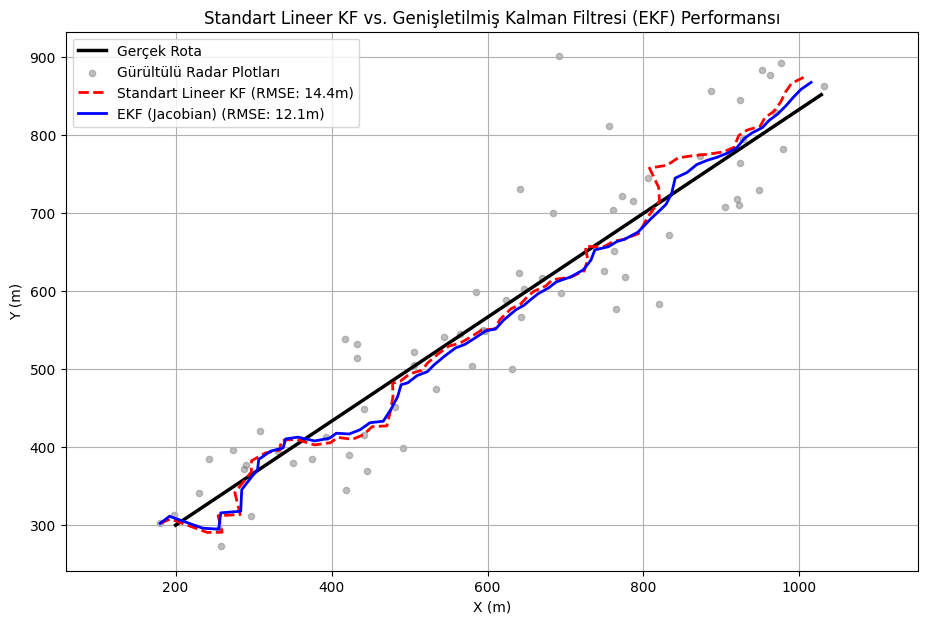

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. RADAR SİMÜLASYONU
# ==========================================
class RadarSimulation:
    def __init__(self, dt, sigma_r, sigma_az):
        self.dt = dt
        self.sigma_r = sigma_r      # Menzil gürültüsü (m)
        self.sigma_az = sigma_az    # Yanca gürültüsü (rad)

    def generate_data(self, num_steps, x0, y0, vx, vy):
        true_states = []
        polar_measurements = []

        x, y = x0, y0
        for _ in range(num_steps):
            true_states.append([x, y, vx, vy])

            # Gerçek Polar Değerler
            r_true = np.sqrt(x**2 + y**2)
            az_true = np.arctan2(y, x)

            # Gauss Gürültülü Polar Ölçümler
            r_meas = r_true + np.random.normal(0, self.sigma_r)
            az_meas = az_true + np.random.normal(0, self.sigma_az)

            polar_measurements.append([r_meas, az_meas])

            x += vx * self.dt
            y += vy * self.dt

        return np.array(true_states), np.array(polar_measurements)


# ==========================================
# 2. STANDART LİNEER KALMAN FİLTRESİ (Linear KF)
# (Ölçümü Kartezyene Çevirip İşler - Dönüşüm Hatalıdır)
# ==========================================
class LinearKalmanFilter:
    def __init__(self, dt, sigma_x, sigma_y, q_var):
        self.dt = dt
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 500.0

        # F: Durum Geçiş Matrisi
        self.F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ])

        # H: Doğrudan Kartezyen Ölçüm Matrisi
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # R: Ölçüm Gürültü Kovaryansı (Sabit Varsayılır)
        self.R = np.diag([sigma_x**2, sigma_y**2])

        # Q: Süreç Gürültü Kovaryansı
        q1 = 0.5 * (dt**2)
        G = np.array([[q1, 0], [0, q1], [dt, 0], [0, dt]])
        self.Q = G @ G.T * q_var

    def initialize(self, x_init, y_init):
        self.x = np.array([[x_init], [y_init], [0.0], [0.0]])

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z_cartesian):
        # z_cartesian = [x_meas, y_meas]^T
        y = z_cartesian - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P


# ==========================================
# 3. GENİŞLETİLMİŞ KALMAN FİLTRESİ (EKF)
# (Polar Ölçümü Doğrudan Jacobian ile İşler)
# ==========================================
class ExtendedKalmanFilter:
    def __init__(self, dt, sigma_r, sigma_az, q_var):
        self.dt = dt
        self.sigma_r = sigma_r
        self.sigma_az = sigma_az

        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 500.0

        self.F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ])

        # R: Polar Uzaydaki Doğal Ölçüm Gürültüsü
        self.R = np.diag([sigma_r**2, sigma_az**2])

        q1 = 0.5 * (dt**2)
        G = np.array([[q1, 0], [0, q1], [dt, 0], [0, dt]])
        self.Q = G @ G.T * q_var

    def initialize(self, r_meas, az_meas):
        x_init = r_meas * np.cos(az_meas)
        y_init = r_meas * np.sin(az_meas)
        self.x = np.array([[x_init], [y_init], [0.0], [0.0]])

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z_polar):
        px, py = self.x[0, 0], self.x[1, 0]
        r_pred = np.sqrt(px**2 + py**2)
        az_pred = np.arctan2(py, px)

        # Non-Lineer Ölçüm Tahmini h(x)
        h_x = np.array([[r_pred], [az_pred]])

        if r_pred < 1e-5:
            return

        # Anlık Doğrusallaştırma: Jacobian Matrisi (H)
        r2 = r_pred**2
        H = np.array([
            [px / r_pred,  py / r_pred,  0, 0],
            [-py / r2,     px / r2,      0, 0]
        ])

        # Fark (Innovation) ve Açı Normalizasyonu
        y = z_polar - h_x
        y[1, 0] = (y[1, 0] + np.pi) % (2 * np.pi) - np.pi

        # Kalman Kazancı ve Güncelleme
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ H) @ self.P


# ==========================================
# 4. BENCHMARK VE KARŞILAŞTIRMA
# ==========================================
if __name__ == "__main__":
    dt = 1.0
    num_steps = 70

    # Yüksek açısal gürültü ekleyelim ki non-lineerlik belirginleşsin
    sigma_r = 15.0               # 15 metre
    sigma_az = np.deg2rad(4.5)   # 4.5 derece
    q_var = 0.05                 # Süreç gürültüsü

    # Simülasyon
    sim = RadarSimulation(dt, sigma_r, sigma_az)
    true_states, polar_measurements = sim.generate_data(num_steps, x0=200, y0=300, vx=12, vy=8)

    # 1. Filtre: Lineer KF (Ölçüm önceden Kartezyene çevrilir)
    # Yaklaşık Kartezyen gürültüler hesaplanır
    sigma_x_approx = sigma_r
    sigma_y_approx = 500 * sigma_az # Ortalama menzil x açısal gürültü

    lkf = LinearKalmanFilter(dt, sigma_x_approx, sigma_y_approx, q_var)
    lkf.initialize(polar_measurements[0,0]*np.cos(polar_measurements[0,1]),
                   polar_measurements[0,0]*np.sin(polar_measurements[0,1]))

    # 2. Filtre: EKF
    ekf = ExtendedKalmanFilter(dt, sigma_r, sigma_az, q_var)
    ekf.initialize(polar_measurements[0, 0], polar_measurements[0, 1])

    lkf_path, ekf_path, raw_plots = [], [], []

    for i in range(num_steps):
        r, az = polar_measurements[i]
        x_m = r * np.cos(az)
        y_m = r * np.sin(az)
        raw_plots.append([x_m, y_m])

        # Lineer KF Adımı
        lkf.predict()
        lkf.update(np.array([[x_m], [y_m]]))
        lkf_path.append(lkf.x[:2].flatten())

        # EKF Adımı
        ekf.predict()
        ekf.update(np.array([[r], [az]]))
        ekf_path.append(ekf.x[:2].flatten())

    lkf_path = np.array(lkf_path)
    ekf_path = np.array(ekf_path)
    raw_plots = np.array(raw_plots)
    true_states = np.array(true_states)

    # Hata Analizi (RMSE Hesaplama)
    lkf_rmse = np.sqrt(np.mean((true_states[:, :2] - lkf_path)**2))
    ekf_rmse = np.sqrt(np.mean((true_states[:, :2] - ekf_path)**2))

    print(f"--- PERFORMANS KARŞILAŞTIRMASI (RMSE) ---")
    print(f"Standart Lineer KF Hatası : {lkf_rmse:.2f} metre")
    print(f"Genişletilmiş KF (EKF) Hatası: {ekf_rmse:.2f} metre")

    # Visualisation
    plt.figure(figsize=(11, 7))
    plt.plot(true_states[:, 0], true_states[:, 1], 'k-', linewidth=2.5, label='Gerçek Rota')
    plt.scatter(raw_plots[:, 0], raw_plots[:, 1], color='gray', alpha=0.5, s=20, label='Gürültülü Radar Plotları')
    plt.plot(lkf_path[:, 0], lkf_path[:, 1], 'r--', linewidth=2, label=f'Standart Lineer KF (RMSE: {lkf_rmse:.1f}m)')
    plt.plot(ekf_path[:, 0], ekf_path[:, 1], 'b-', linewidth=2, label=f'EKF (Jacobian) (RMSE: {ekf_rmse:.1f}m)')

    plt.title('Standart Lineer KF vs. Genişletilmiş Kalman Filtresi (EKF) Performansı')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

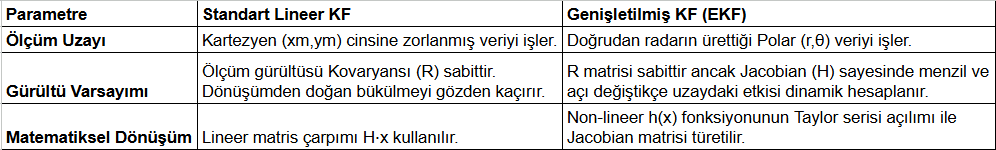